In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Lecture 12 (28/02/25)

### Numerical Integration: Trapezoidal Method, Simpson's 1/3rd Method and Adaptive Integration

## 12.1 Trapezoidal Method
The Trapezoidal method numerically finds a definite integral of a function $f(x)$ between $a$ and $b$ by finding the Riemann Sum of the areas of $n$ different trapezoids defined by their common width $dx=(b-a)/n$ and heights $f(a)$ and $f(b)$. 

In [2]:
def f(x):
    return np.exp(x)

def trap_int(f, a, b, eps, N):
    
    I = [] # Store integral values
    
    for i in range(1, N):
        n = 10**i
        x = np.linspace(a, b, n + 1)
        y = f(x)
        dx = (b-a)/n

        I_n = (dx/2) * (2*np.sum(y[1:-1]) + y[0] + y[-1]) # Trapezoidal Integral
        I.append(I_n) 

        if len(I)>1 and abs(I[-1]-I[-2])<eps: # Break when difference is less than eps
            break

    return print(f'Integral = {I[-1]} \nError = {abs(I[-1]-I[-2])} \nIterations = {i}')
        
trap_int(f, -1, 1, 1e-10, 20)

Integral = 2.3504023872883852 
Error = 7.756462139241194e-11 
Iterations = 6


## 12.2 Simpson's 1/3rd Method
Simpson's 1/3rd method numerically finds a definite integral of a function $f(x)$ between $a$ and $b$ by finding the Riemann Sum of $n$ different areas with a width of $dx=(b-a)/n$ and fitting a quadratic function between $f(x_{i-1})$, $f(x_{i})$ and $f(x_{i+1})$. The resulting coefficients are determined analytically before computing the summation. 

In [3]:
def f(x):
    return np.exp(x)

def simp_int(f, a, b, eps, N):
    
    I = [] # Store integral values
    
    for i in range(1, N):
        n = 10**i
        x = np.linspace(a, b, n + 1)
        y = f(x)
        dx = (b-a)/n

        I_n = (dx/3) * (y[0] + y[-1] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-2:2])) # Simpson Integral
        I.append(I_n) 

        if len(I)>1 and abs(I[-1]-I[-2])<eps: # Break when difference is less than eps
            break

    return print(f'Integral = {I[-1]} \nError = {abs(I[-1]-I[-2])} \nIterations = {i}')
        
simp_int(f, -1, 1, 1e-10, 20)

Integral = 2.350402387287603 
Error = 2.0872192862952943e-13 
Iterations = 4


## 12.3 Adaptive Integration
Adaptive integration applies a numerical integration method such as the Trapezoidal method or Simpson's 1/3rd method to recursively find the integral over smaller and smaller subdivisions of the interval until the difference between the integrals drops below the desired tolerance. This method adapts to the nature of the curve by determining the necessary degree of subdivision based on how much the integral changes with each iteration.

In [4]:
def f(x):
    return np.exp(x)

def trap_rule(f, a, b):
    return ((b - a)/2) * (f(a) + f(b))

def simp_rule(f, a, b):
    m = (a + b)/2
    return ((b - a)/6) * (f(a) + 4*f(m) + f(b))

Iter = 0

def adaptive_int(f, a, b, eps, method, depth=0):
    global Iter
    Iter = max(Iter, depth) # Keep track of max recursion depth

    # Using method, compute integral for [a, b], and [a, m] + [m, b]
    if method == 'trap':    
        I1 = trap_rule(f, a, b)
        m = (a + b)/2
        I2 = trap_rule(f, a, m) + trap_rule(f, m, b)

    elif method == 'simp':
        I1 = simp_rule(f, a, b)
        m = (a + b)/2
        I2 = simp_rule(f, a, m) + simp_rule(f, m, b)
    else:
        raise ValueError("Invalid method. Use 'trap' or 'simps'")

    # Return if integral is within eps, else continue recursion
    if np.abs(I2 - I1) < eps:
        return I2, np.abs(I2 - I1)
    else:
        I_left, left_err = adaptive_int(f, a, m, eps, method, depth + 1)
        I_right, right_err = adaptive_int(f, m, b, eps, method, depth + 1)
        return I_left + I_right, max(left_err, right_err)

I, err = adaptive_int(f, -1, 1, 1e-10, method='simp')
print(f'Integral = {I} \nMax Error = {err} \nMax Recursion Depth = {Iter}')

Integral = 2.3504023873362465 
Max Error = 2.5962232363951898e-11 
Max Recursion Depth = 6


# Lecture 15 (19/03/25)
### Random Number Generation

## 15.1 Random Number Generation
We can verify that np.random.random() generates random numbers from a uniform distribution by generating a histogram of the data.

In [5]:
def uniform_dist(N, bin_size):
    r = np.random.random(int(N))
    bins = int(1/bin_size)
    counts = np.zeros(bins)

    for i in range(N):
        n = int(r[i]*bins)
        counts[n] += 1

    freq = counts/N
    
    return freq, bins

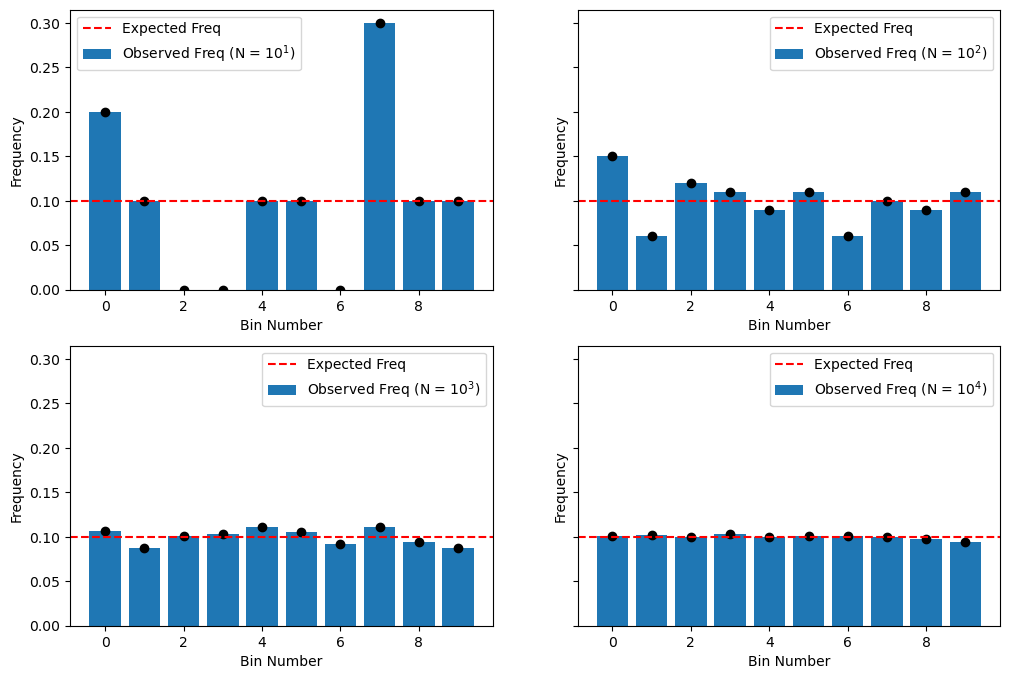

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for i in range(4):
    freq, bins = uniform_dist(10**(i+1), 0.1)
    bin_pos = np.arange(bins)
    row, col = divmod(i, 2)
    ax = axes[row, col]
    ax.bar(bin_pos, freq, label=f'Observed Freq (N = 10$^{i+1}$)')
    ax.scatter(bin_pos, freq, c='k')
    ax.axhline(1/bins, c='r', ls='--', label='Expected Freq')
    ax.set_xlabel('Bin Number')
    ax.set_ylabel('Frequency')
    ax.legend()
plt.show()

The Central Limit Theorem (CLT) tells us that $\sigma \propto N^{-1/2}$. We can test this for a uniform distribution.

Slope = -0.495


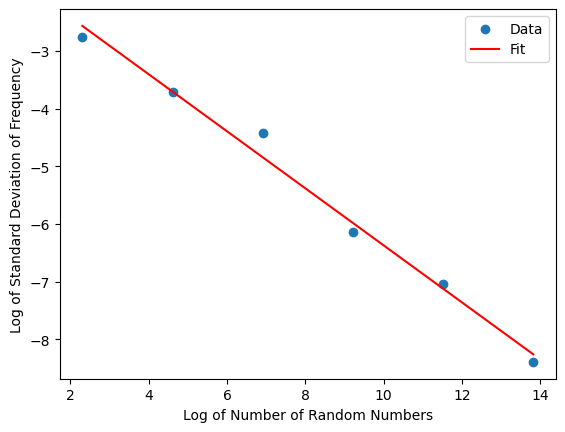

In [7]:
exp = 6
std = np.zeros(exp)
N = np.zeros(exp)
for i in range(exp):
    freq, bins = uniform_dist(10**(i+1), 0.1)
    std[i] = np.std(freq)
    N[i] = 10**(i+1)

log_std = np.log(std)
log_N = np.log(N)

p, q = np.polyfit(log_N, log_std, 1)

print(f'Slope = {p:.3f}')

plt.scatter(log_N, log_std, label='Data')
plt.plot(log_N, p*log_N+q, c='r', label='Fit')
plt.xlabel(r'Log of Number of Random Numbers')
plt.ylabel('Log of Standard Deviation of Frequency')
plt.legend()
plt.show()

# Lecture 16 (21/03/25)
### Monte-Carlo Integration, Law of Large Numbers and Central Limit Theorem

## 16.1 Monte-Carlo Integration
This method of integration uses the proportion of randomly generated points in the interval [c, d] that lie below f(x) in the interval [a, b]. This ratio is multiplied with the total sampling area (d-c)(b-a) to determine the value of the integral. The larger the sampling, the more the accurate this method is likely to be.

Since this method is based on random number generation, the results follow the central limit theorem. Therefore the error in estimating the integral behaves like the standard deviation of the sample mean, which goes as:

$$\displaystyle \text{Standard Error} \propto \frac{\sigma}{\sqrt{N}}$$

In [8]:
def f(x):
    return np.exp(x)

def monte_carlo_int(f, xlim, ylim, N, Iter):
    I = np.zeros(Iter)
    A = (xlim[1] - xlim[0])*(ylim[1] - ylim[0])

    for i in range(Iter):
        x = xlim[0] + np.random.random(N)*(xlim[1] - xlim[0])
        y = ylim[0] + np.random.random(N)*(ylim[1] - ylim[0])
        f_x = f(x)
        
        hits = np.sum(y <= f_x) # Count number of "hits"

        I[i] = A*(hits/N)

    return I

N = 10000
Iter = 1000
Int = monte_carlo_int(f, [-1, 1], [0, 6], N, Iter)
I_m = np.mean(Int)
I_std = np.std(Int)
print(f'Integral = {I_m} \nError = {I_std/np.sqrt(N)}')

Integral = 2.352972 
Error = 0.0004575205018357101


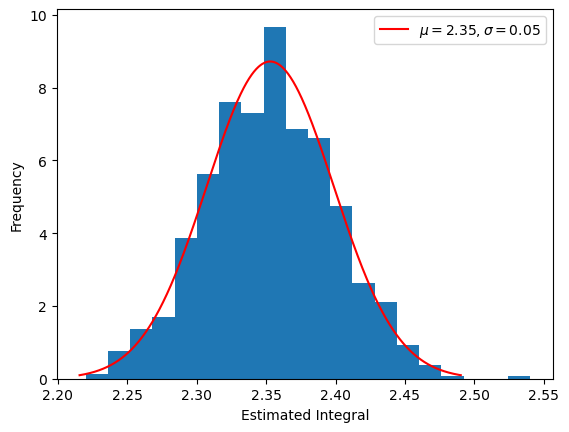

In [9]:
# Histogram of Integral Estimate
def gaussian(x, mu, std):
    return np.exp(-(x-mu)**2/(2*std**2))/(np.sqrt(2*np.pi)*std)

I_m = np.mean(Int)
I_std = np.std(Int)
x = np.linspace(I_m-3*I_std, I_m+3*I_std, 1000)

plt.hist(Int, 20, density=True)
plt.plot(x, gaussian(x, I_m, I_std), color='r', label=rf'$\mu={I_m:.2f}, \sigma={I_std:.2f}$')
plt.xlabel('Estimated Integral')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.show()

## 16.2 Law of Large Numbers and Central Limit Theorem
The Law of Large Numbers states that the average of the results obtained from a large number of independent random samples converges to the value of the population mean ($\mu$). The sample mean is given by:

$$\displaystyle \bar{x}_N = \frac{1}{N} \sum_i x_i$$

This law can be stated in two forms, the strong and weak forms: 

1. Weak form: For a small margin $\epsilon$, there is a very high probability of the sample mean being within the margin of the population mean as $N\rightarrow\infty$.
$$\displaystyle \lim_{N \rightarrow\infty} Pr(|\bar{x}_N - \mu| < \epsilon) = 1$$

2. Strong form: As $N\rightarrow\infty$ the probability that the sample mean converges to the population mean is equal to one.
$$\displaystyle Pr\left(\lim_{N \rightarrow\infty} \bar{x}_N = \mu\right) = 1$$


The Central Limit Theorem (CLT) states that as $N\rightarrow\infty$, the difference between the sample average $\bar{x}_N$ and its limit $\mu$ (following from the Law of Large Numbers) approaches a normal distribution with mean $\mu$ and variance $\sigma^2/N$.

$$\displaystyle \lim_{N \rightarrow\infty} P(\overline{x}_N) = \frac{1}{\sqrt{2\pi(\sigma^2/N)}} \exp\left( -\frac{(\overline{x}_N - \mu)^2}{2(\sigma^2/N)} \right)$$

This holds true regardless of the distribution from which the samples are chosen and is stronger than both the strong and weak forms of the Law of Large Numbers.

In [10]:
def CLT(N, iterations):
    sample_m = np.zeros(Iter)
    for i in range(Iter):
        nums = np.random.random(N)
        sample_m[i] = np.mean(nums)

    return sample_m

sample_m = CLT(1000, 10000)
x_m = np.mean(sample_m)
x_std = np.std(sample_m)
err = np.abs(0.5 - x_m)

print(f'Population Mean = {0.5} \nSample Mean = {x_m} \nError = {err}')

Population Mean = 0.5 
Sample Mean = 0.4996594281262183 
Error = 0.0003405718737817254


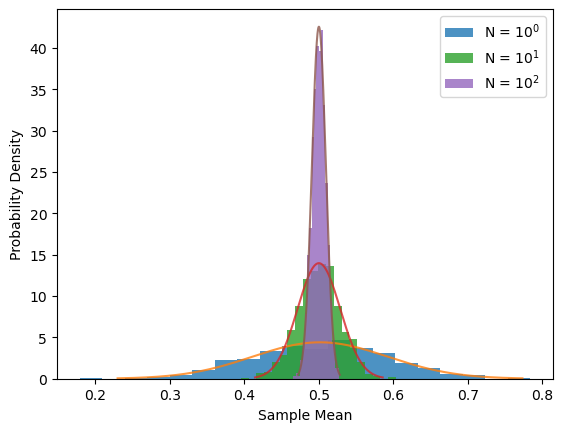

In [11]:
def gaussian(x, mu, std):
    return np.exp(-(x-mu)**2/(2*std**2))/(np.sqrt(2*np.pi)*std)

trials = 3
x_m = np.zeros(trials)
x_std = np.zeros(trials)

for i in range(trials):
    sample_m = CLT(10**(i+1), 10000)
    x_m[i] = np.mean(sample_m)
    x_std[i] = np.std(sample_m)
    x = np.linspace(x_m[i]-3*x_std[i], x_m[i]+3*x_std[i], 1000)
    
    plt.hist(sample_m, 20, alpha=0.8, density=True, label=rf'N = $10^{i}$')
    plt.plot(x, gaussian(x, x_m[i], x_std[i]), alpha=0.8)

plt.xlabel('Sample Mean')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

# Lecture 17 (26/03/25)
### Coin-Toss Experiment

## Coin-Toss Experiment
Consider a Mone-Carlo simulation using a coin that comes up heads (H) with a probability p, and tails (T) with a probability (1-p). 

In [12]:
def coin_toss(N, p):
    num = np.random.random(N)
    result = ''
    H_count = 0
    T_count = 0 
    for i in range(N):
        if num[i] < p:
            result += 'H'
            H_count += 1
        else:
            result += 'T'
            T_count += 1

    H_freq = H_count/N
    T_freq = T_count/N
    
    return result, H_freq, T_freq

result, H_freq, T_freq = coin_toss(100, 0.3)

print(f'Probability of H = {H_freq} \nProbability of T = {T_freq} \nResult = {result}')

Probability of H = 0.31 
Probability of T = 0.69 
Result = TTTTHTHTHHTTTHHHTHHHTHHHTHTTTTHHTTTTTTTTTHTHHHTTTHTTTTHTTTTTTTTTTTTTTHTTTHHTHHTTTTTTTTTHTTTTHTTTHTHT


Probability of H = 0.39986 ± 0.00051 
Probability of T = 0.60014 ± 0.00051


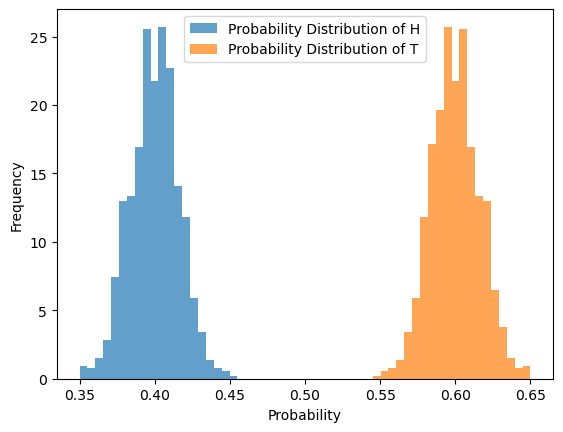

In [13]:
trials = 1000
P_H = np.zeros(trials)
P_T = np.zeros(trials)

for i in range(1000):
    p = 0.4
    N = 1000
    result, H_freq, T_freq = coin_toss(N, p)
    P_H[i] = H_freq
    P_T[i] = T_freq

H_m = np.mean(P_H)
T_m = np.mean(P_T)
H_err = np.std(P_H)/np.sqrt(N)
T_err = np.std(P_T)/np.sqrt(N)


print(f'Probability of H = {H_m:.5f} ± {H_err:.5f} \nProbability of T = {T_m:.5f} ± {T_err:.5f}')

plt.hist(P_H, 20, alpha=0.7, density=True, label='Probability Distribution of H')
plt.hist(P_T, 20, alpha=0.7, density=True, label='Probability Distribution of T')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Lecture 19 (04/04/25)
### Random Permutation and Lagrangian Interpolation

## 19.1 Random Permutations
To generate a permutation of a given list of objects (i.e. shuffle the elements), we can go through the list by index number and swap items with any element after it, ensuring that swapped objects are not moved again. 

In [14]:
def shuffle(array):
    N = len(array)
    for i in range(N-1):
        l = i + int((N - i) * np.random.random())
        temp = array[i]
        array[i] = array[l]
        array[l] = temp
    return print(array)

arr = np.arange(10)
shuffle(arr)

[2 5 4 8 7 3 0 1 6 9]


## 19.2 Lagrangian Interpolation
Lagrangian Interpolation is a method to find a polynomial that passes through a set of known points $\{(x_0, y_0), (x_1, y_1), ... (x_n, y_n)\}$. The interpolating polynomial is given by:

$$\displaystyle P(x) = \sum_{i=0}^{n} y_i \cdot \ell_i(x), \quad \text{where} \quad \ell_i(x) = \prod_{\substack{j=0 \\ j \ne i}}^{n} \frac{x - x_j}{x_i - x_j}$$

In [15]:
def lagrange_interpolation(x, y, x_0):
    result = 0

    for i in range(len(x)):
        li = 1
        for j in range(len(x)):
            if i != j:
                li *= (x_0 - x[j]) / (x[i] - x[j])
                
        result += y[i] * li

    return result

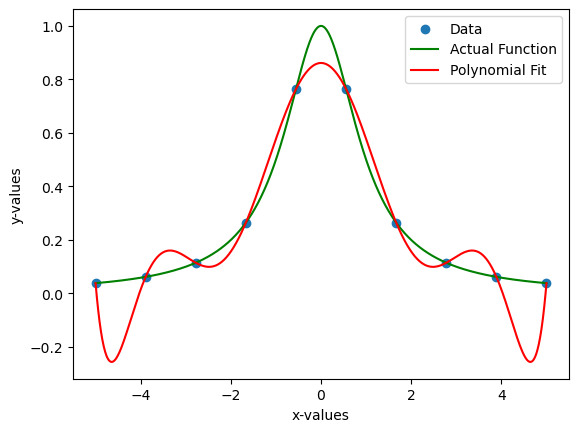

In [16]:
def f(x):
    return 1/(1+x**2)

x_data = np.linspace(-5, 5, 10)
y_data = f(x_data)

x = np.linspace(-5, 5, 1000)
y = np.array([lagrange_interpolation(x_data, y_data, x_vals) for x_vals in x])

plt.scatter(x_data, y_data, label='Data')
plt.plot(x, f(x), c='g', label='Actual Function')
plt.plot(x, y, c='r', label='Polynomial Fit')
plt.xlabel('x-values')
plt.ylabel('y-values')
plt.legend(loc='upper right')
plt.show()

Using interpolation, we can also find value of the estimated function for any intermediate point between $(x_0, y_0)$ and $(x_n, y_n)$. However, it is not reliable for extending beyond this range.

In [17]:
x_0 = 1.34
y_0 = lagrange_interpolation(x_data, y_data, x_0)

print(f'Interpolation Value = {y_0} \nTrue Value = {f(x_0)} \nError = {np.abs(f(x_0) - y_0):.3e}')

Interpolation Value = 0.4106579774277499 
True Value = 0.3577049649449134 
Error = 5.295e-02


# Lecture 20 (09/04/25)
## Least-Square Fitting

## 20.1 Least-Square Fitting
Least square fitting fits a straigh line of the form $y=a_0+a_1x$ to a set of points $\{(x_0, y_0), (x_1, y_1), ... (x_n, y_n)\}$ by minimising the residuals from the fitted line to determine the coefficients. For a linear function, we find the coefficients are:

$$\displaystyle a_0 = \frac{\overline{x^2} \cdot \overline{y} - \overline{x} \cdot \overline{y x}}{\overline{x^2} - \overline{x}^2}$$

$$\displaystyle a_1 = \frac{-\overline{x} \cdot \overline{y} + \overline{y x}}{\overline{x^2} - \overline{x}^2}$$

Where the bars of the terms represent averages over the data. This same logic can be extended to more complex polynomials. 

In [18]:
# Generate Data Fit
a = 10
b = 3
eps = 1
x = np.arange(0, 50)
y = np.zeros(len(x))

for i in x:
    eta = 10*np.random.rand()-5
    y[i] = a + b*i + eps*eta

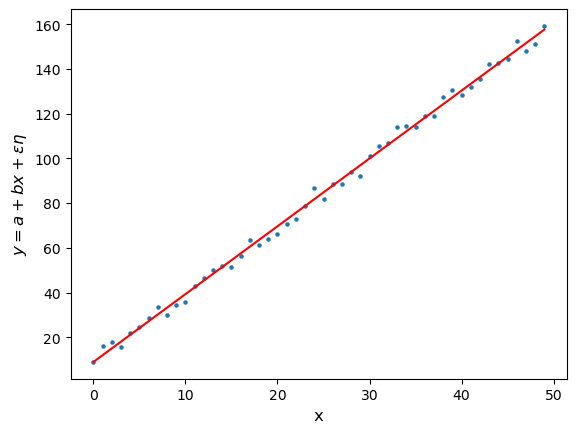

In [19]:
# Linear fit
def Fit(x, y):
    XY = np.mean(x*y)
    Y = np.mean(y)
    X = np.mean(x)
    Xsq = np.mean(x**2)

    A = (1/(Xsq-X**2))*(Xsq*Y - X*XY)
    B = (1/(Xsq-X**2))*(-X*Y + XY)

    return A, B

q, p = Fit(x, y)

plt.scatter(x, y, s=5)
plt.plot(x, p*x+q, c='r')
plt.xlabel(r'x', fontsize=12)
plt.ylabel(r'$y = a + bx + \epsilon\eta$', fontsize=12)
plt.show()

As epsilon grows, we expect the accuracy of the fit to reduce since the data is "noisier". This has been shown below.

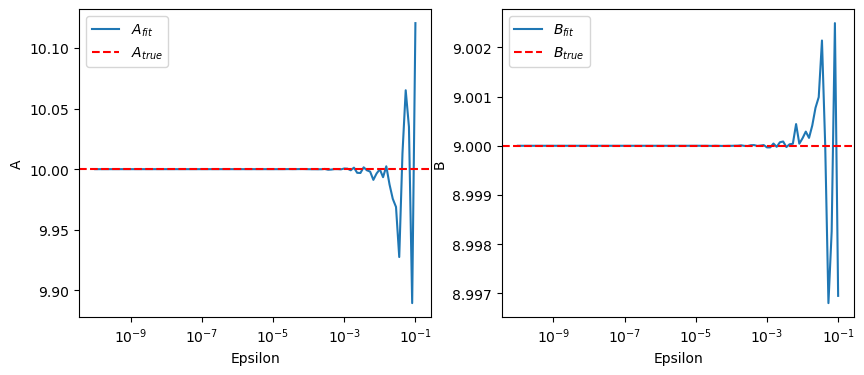

In [24]:
a = 10
b = 9

eps_values = np.logspace(-1, -10, 100)
A_fit = []
B_fit = []

for eps in eps_values:
    eta = 10*np.random.rand(len(x))-5 
    y = a + b*x + eps*eta    
    A, B = Fit(x, y)
    A_fit.append(A)
    B_fit.append(B)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(eps_values, A_fit, label='$A_{fit}$')
plt.xlabel('Epsilon')
plt.ylabel('A')
plt.axhline(a, linestyle='--', c='r', label='$A_{true}$')
plt.xscale('log')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(eps_values, B_fit, label='$B_{fit}$')
plt.xlabel('Epsilon')
plt.ylabel('B')
plt.axhline(b, linestyle='--', c='red', label='$B_{true}$')
plt.xscale('log')
plt.legend()
plt.show()